In [9]:
import pandas as pd

In [10]:
df = pd.read_excel("Churn.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.875456
std,0.368612,24.559481,30.090047,2266.655975
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [14]:
df.drop(['customerID', 'gender', 'PaymentMethod'], axis = 1, inplace = True)

In [15]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,29.85,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,56.95,1889.50,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,53.85,108.15,Yes
3,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,42.30,1840.75,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,70.70,151.65,Yes


In [16]:
columns_to_check_unique_values = ['Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','Churn']

for col in columns_to_check_unique_values:
    print(f"{col}:{df[col].unique()}")

Partner:['Yes' 'No']
Dependents:['No' 'Yes']
PhoneService:['No' 'Yes']
MultipleLines:['No phone service' 'No' 'Yes']
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:['No' 'Yes' 'No internet service']
OnlineBackup:['Yes' 'No' 'No internet service']
DeviceProtection:['No' 'Yes' 'No internet service']
TechSupport:['No' 'Yes' 'No internet service']
StreamingTV:['No' 'Yes' 'No internet service']
StreamingMovies:['No' 'Yes' 'No internet service']
Contract:['Month-to-month' 'One year' 'Two year']
PaperlessBilling:['Yes' 'No']
Churn:['No' 'Yes']


In [18]:
columns_to_transform1 = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

columns_to_transform2 = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

df[columns_to_transform1] = df[columns_to_transform1].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)

df[columns_to_transform2] = df[columns_to_transform2].replace({'Yes': 1, 'No': 0, 'No internet service': 2}).infer_objects(copy=False)

df['MultipleLines'] = df['MultipleLines'].replace({'Yes': 1, 'No': 0, 'No phone service': 2}).infer_objects(copy=False)

df['InternetService'] = df['InternetService'].replace({'DSL': 1, 'No': 0, 'Fiber optic': 2}).infer_objects(copy=False)

df['Contract'] = df['Contract'].replace({'Month-to-month': 1, 'One year': 0, 'Two year': 2}).infer_objects(copy=False)

In [19]:
df.dtypes

SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sc = ['tenure','MonthlyCharges', 'TotalCharges']
df[sc] = scaler.fit_transform(df[sc])

In [21]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,0,1,0,-1.277445,0,2,1,0,1,0,0,0,0,1,1,-1.160323,-0.992733,0
1,0,0,0,0.066327,1,0,1,1,0,1,0,0,0,0,0,-0.259629,-0.172238,0
2,0,0,0,-1.236724,1,0,1,1,1,0,0,0,0,1,1,-0.362660,-0.958187,1
3,0,0,0,0.514251,0,2,1,1,0,1,1,0,0,0,0,-0.746535,-0.193746,0
4,0,0,0,-1.236724,1,0,2,0,0,0,0,0,0,1,1,0.197365,-0.938994,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,-0.340876,1,1,1,1,0,1,1,1,1,0,1,0.665992,-0.127675,0
7039,0,1,1,1.613701,1,1,2,0,1,1,0,1,1,0,1,1.277533,2.242681,0
7040,0,1,1,-0.870241,0,2,1,1,0,0,0,0,0,1,1,-1.168632,-0.853046,0
7041,1,1,0,-1.155283,1,1,2,0,0,0,0,0,0,1,1,0.320338,-0.870629,1


In [22]:
import matplotlib.pyplot as plt

import seaborn as sns

In [23]:
corr_matrix = df.corr()

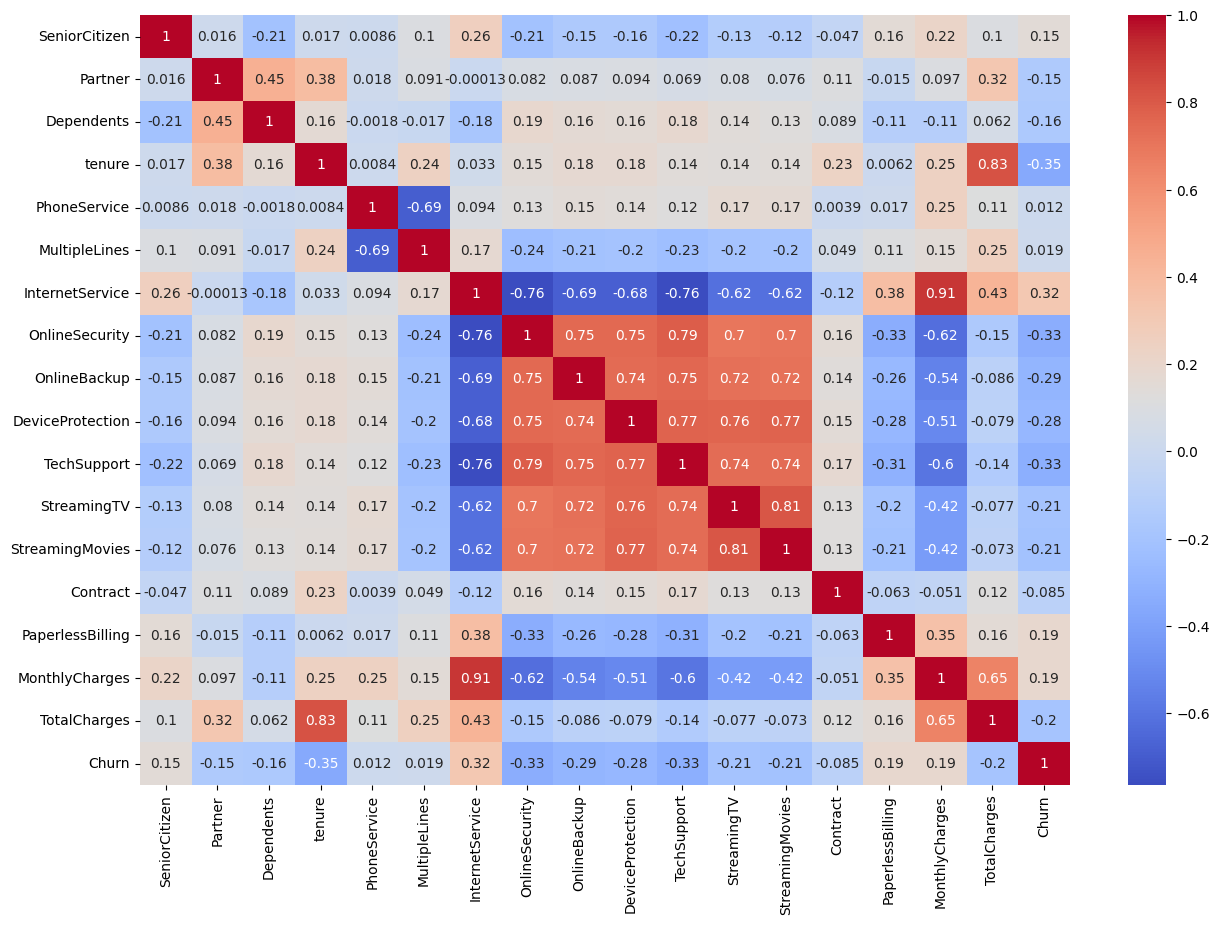

In [25]:
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

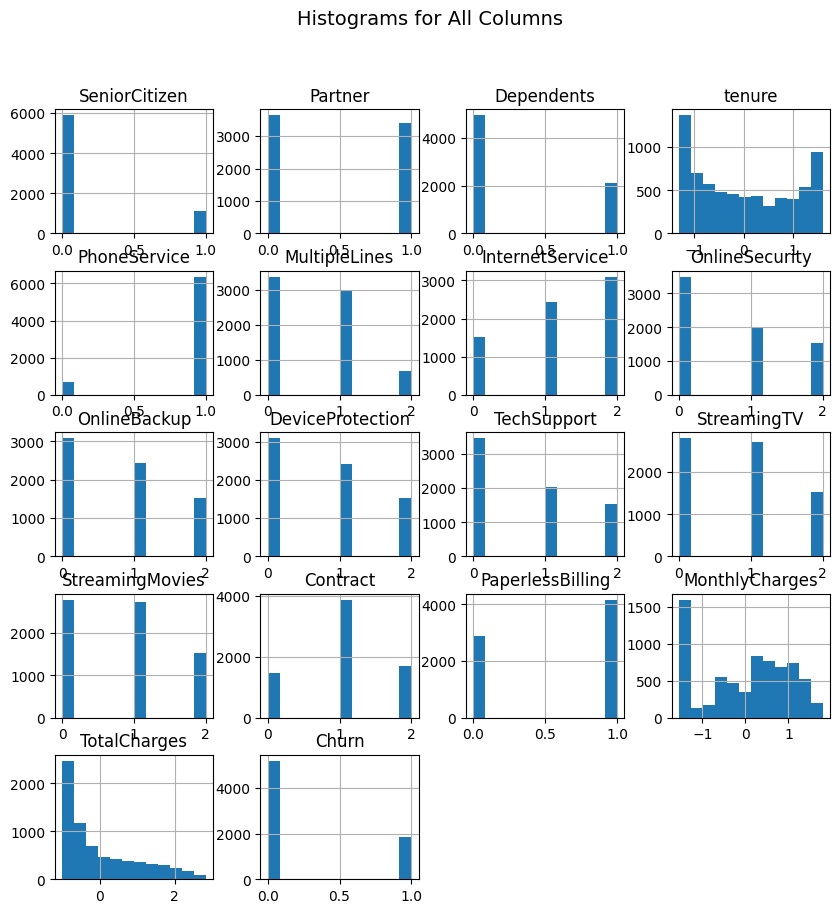

In [26]:
df.hist(figsize=(10, 10), bins=12)
plt.suptitle("Histograms for All Columns", fontsize=14)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

In [30]:
X = df.drop(['Churn','SeniorCitizen'], axis = 1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Logistic Regression
lr_model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

#RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 200,max_depth=10,class_weight = 'balanced',random_state = 42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, lr_pred)
accuracy2 = accuracy_score(y_test, rf_pred)

print("LR Accuracy:",accuracy1*100)
print("RF Accuracy:",accuracy2*100)

LR Accuracy: 76.00567912920019
RF Accuracy: 77.28348319924278


In [33]:
from sklearn.metrics import classification_report

lr_cr = classification_report(y_test, lr_pred)
rf_cr = classification_report(y_test, rf_pred)

print('LR Classification Report', lr_cr)
print('RF Classification Report', rf_cr)

LR Classification Report               precision    recall  f1-score   support

           0       0.91      0.75      0.82      1539
           1       0.54      0.80      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113

RF Classification Report               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1539
           1       0.57      0.70      0.63       574

    accuracy                           0.77      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.79      0.77      0.78      2113



In [34]:
from sklearn.metrics import recall_score

In [35]:
lr_rs = recall_score(y_test, lr_pred)
rf_rs = recall_score(y_test, rf_pred)

print('LR Recall Score', lr_rs*100)
print('RF Recall Score', rf_rs*100)

LR Recall Score 79.61672473867596
RF Recall Score 70.03484320557492


In [36]:
from sklearn.metrics import precision_score

lr_ps = precision_score(y_test, lr_pred)
rf_ps = precision_score(y_test, rf_pred)

print('LR Precision Score', lr_ps*100)
print('RF Precision Score', rf_ps*100)

LR Precision Score 53.955135773317586
RF Precision Score 56.61971830985916


In [37]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print('LR Confusion Matrix', lr_cm)
print('RF Confusion Matirx', rf_cm)

LR Confusion Matrix [[1149  390]
 [ 117  457]]
RF Confusion Matirx [[1231  308]
 [ 172  402]]


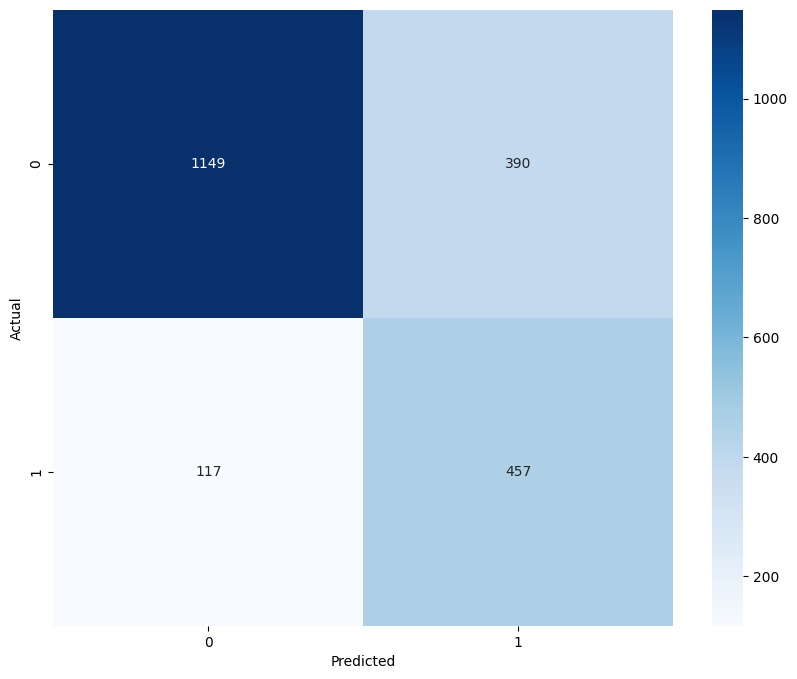

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(lr_cm, annot=True, fmt = 'd', cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [56]:
import joblib

joblib.dump(lr_model,"Churn_Prediction_Model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']